<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap04/4_1_Composing_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colabで開く"/></a>

# ノートブック 4.1 -- ネットワークの合成

このノートブックの目的は、あるニューラルネットワークを別のニューラルネットワークに入力したときに何が起こるかを理解することです。4.1の例と同様の内容を扱い、両方のネットワークを変化させます。

以下のセルを順番に実行してください。様々な場所に「TODO」という言葉が表示されます。これらの場所で指示に従い、何が起こるか予測したり、関数を完成させるコードを書いたりしてください。

間違いを見つけたり、提案がある場合は udlbookmail@gmail.com までご連絡ください

In [ ]:
# 数学ライブラリをインポート
import numpy as np
# プロットライブラリをインポート
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Noto Sans CJK JP'

In [12]:
# 正規化線形ユニット（ReLU）関数を定義
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [13]:
# 1つの入力、1つの出力、3つの隠れユニットを持つ浅いニューラルネットワークを定義
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # 初期の線形演算
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # 活性化関数
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # 活性化に重みを掛ける
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # 重み付き活性化を結合してyオフセットを追加
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # 計算した全てを返す
  return y

In [14]:
# 2つの浅いニューラルネットワークとそれらの合成をプロット
def plot_neural_two_components(x_in, net1_out, net2_out, net12_out=None):

  # 2つのネットワークを別々にプロット
  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_in, net1_out,'r-')
  ax[0].set_xlabel('ネットワーク1の入力'); ax[0].set_ylabel('ネットワーク1の出力')
  ax[0].set_xlim([-1,1]);ax[0].set_ylim([-1,1])
  ax[0].set_aspect(1.0)
  ax[1].plot(x_in, net2_out,'b-')
  ax[1].set_xlabel('ネットワーク2の入力'); ax[1].set_ylabel('ネットワーク2の出力')
  ax[1].set_xlim([-1,1]);ax[1].set_ylim([-1,1])
  ax[1].set_aspect(1.0)
  plt.show()

  if net12_out is not None:
    # それらの合成をプロット
    fig, ax = plt.subplots()
    ax.plot(x_in ,net12_out,'g-')
    ax.set_xlabel('ネットワーク1の入力'); ax.set_ylabel('ネットワーク2の出力')
    ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
    ax.set_aspect(1.0)
    plt.show()

2つのネットワークを定義しましょう。どのネットワークかを明確にするために、全ての変数の前にn1_とn2_という接頭辞を付けます。入力と出力の範囲は[-1,1]のみを考えます。

findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.


findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not found.
findfont: Font family 'Meiryo' not

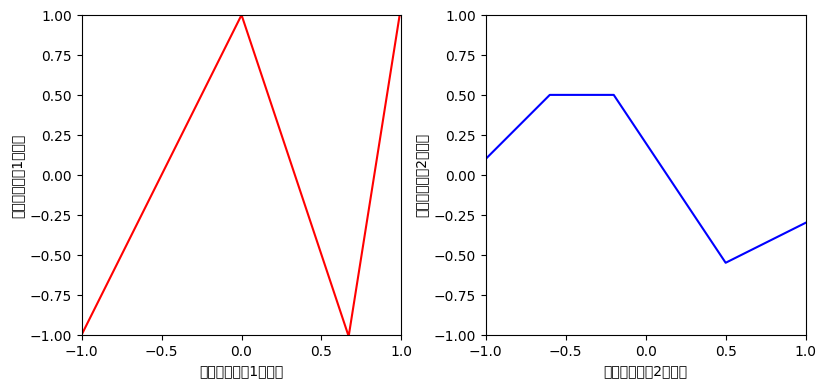

In [19]:
# 最初のニューラルネットワークのパラメータを定義して実行
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# 2番目のニューラルネットワークのパラメータを定義して実行
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# 2つの入力を表示
x = np.arange(-1,1,0.001)
# これらの入力値それぞれに対して第1および第2のニューラルネットワークを実行
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# 両方のグラフをプロット
plot_neural_two_components(x, net1_out, net2_out)

In [ ]:
# TODO
# 紙を取り出して、最初のネットワークの出力を2番目のネットワークに入力したときに
# 何が起こるか予測して描いてください。最初のネットワークの入力と
# 2番目のネットワークの出力の関係を描いてください。

In [ ]:
# 予測が正しかったか確認しましょう

# TODO 最初のネットワークの出力を2番目のネットワークに入力する（この行を置き換える）
net12_out = np.zeros_like(x)

# 3つ全てのグラフをプロット
plot_neural_two_components(x, net1_out, net2_out, net12_out)

In [ ]:
# 少し変更してみましょう。2番目のネットワークを変更するとどうなるでしょうか？（*-1の変更に注目）
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

In [ ]:
# TODO
# 紙を取り出して、最初のネットワークの出力を修正された2番目のネットワークに入力したときに
# 何が起こるか予測して描いてください。最初のネットワークの入力と
# 2番目のネットワークの出力の関係を描いてください。

In [ ]:
# 予測ができたら、このコードを実行して正しかったか確認してください
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

In [ ]:
# また変更してみましょう。最初のネットワークを変更するとどうなるでしょうか？（変更に注目）
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1*0.5, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

In [ ]:
# TODO
# 紙を取り出して、修正された最初のネットワークの出力を元の2番目のネットワークに入力したときに
# 何が起こるか予測して描いてください。最初のネットワークの入力と
# 2番目のネットワークの出力の関係を描いてください。

In [ ]:
# 予測ができたら、このコードを実行して正しかったか確認してください
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

In [ ]:
# また変更してみましょう。最初と2番目のネットワークが同じだとどうなるでしょうか？
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out_new = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new)

In [ ]:
# TODO
# 紙を取り出して、最初のネットワークの出力を自分自身のコピーに入力したときに
# 何が起こるか予測して描いてください。最初のネットワークの入力と
# 2番目のネットワークの出力の関係を描いてください。

In [ ]:
# 予測ができたら、このコードを実行して正しかったか確認してください
net12_out = shallow_1_1_3(net1_out, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new, net12_out)

In [ ]:
# TODO
# 元の最初のネットワークの出力を、元の最初のネットワークの2番目のコピーに入力し、
# その出力を元の2番目のネットワークに入力したときに何が起こるか考えてください（つまり3層のネットワーク）
# 出力に合計で何個の線形領域があるでしょうか？
net123_out = shallow_1_1_3(net12_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net12_out, net2_out, net123_out)

In [ ]:
# TODO
# 最初のネットワークのN個のコピーを実行し、1番目の結果を2番目に、2番目を3番目に、
# というように次々と入力し、最後に元の2番目のネットワーク（上の青い曲線）に
# 結果を渡した場合、線形領域はいくつになるでしょうか？

# 結論：非常に少ないパラメータで、非常に多くの線形領域を作ることができますが、
# それらは複雑な方法で互いに依存しており、直感的に理解するのがすぐに困難になります。